In [135]:
import numpy as np 
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense 
import matplotlib.pyplot as plt

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

## 2- Neural Networks

In Course 1, you implemented logistic regression. This was extended to handle non-linear boundaries using polynomial regression. For even more complex scenarios such as image recognition, neural networks are prefered.

### 2.1 Problem Statement

In this exercise, you will use a neural network to recognize two handwritten digits, zero and one. This is binary classfication task. Automated handwritten digit recognition is widely used today - from recognizing zip codes (postal codes) on mail envelopes to recognizing amounts written on bank checks. You will extend this network to recognize all 10 digits (0-9) in a future assignment. 

### 2.2 Dataset

* The `load_data()` function shown below loads the data into variables `X` and `y`
* The data set contains 1000 training examples of handwritten digits, here limited to zero and one.
  * Each training example is a 20-pixel grayscale image of the digit.
    *  Each pixel is represented by a floating-point number indicating the grayscale intensity at that location
    *  The 20 by 20 grid of pixel is "unrolled" into a 400-dimensional vector
    *  Each training example becomes a single row in our data matrix `X`
    *  This gives us a 1000 x 400 `X` where every row is a training example of handwritten digit image

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 
* The second part of the training set is 1000 x 1 dimensional vector `y` that contains labels for the training set.
  * `y = 0` if the image is of the digit `0`, `y = 1` if the image is of the digit `1`

In [136]:
def load_data(): 
    X = np.load("data/X.npy") 
    y = np.load("data/y.npy") 
    X = X[0:1000]
    y = y[0:1000]
    return X, y

In [137]:
X, y = load_data()
print('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [138]:
print('The first element of y is ', y[0, 0]) 
print('The last element of y is: ', y[-1, 0])

The first element of y is  0
The last element of y is:  1


### 2.2.2 Check the dimensions of your variables 

Another way to get familiar with your data is to view its dimensions. Please print the shape of `X` and `y` and see how many training examples you have in your dataset.

In [139]:
print('The shape of X is: ' + str(X.shape))
print('The shape of y is: ' + str(y.shape))

The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


### 2.2.3 Visualizing the Data

You will begin by visualizing a subset of the training set
* In the cell below, the code randomly selects 64 rows from `X`, maps each row back to a 20 pixel by 20 pixel grayscale image and displays the images together
* The label for each image is displayed above the image

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape
fig, axes = plt.subplots(8, 8, figsize=(8, 8)) 
fig.tight_layout(w_pad=0.1, h_pad=0.2)

for i, ax in enumerate(axes.flat): 
    random_index = np.random.randint(m) 

    X_random_reshaped = X[random_index].reshape((20, 20)).T

    ax.imshow(X_random_reshaped, cmap='gray') 

    ax.set_title(y[random_index, 0])
    ax.set_axis_off()

NameError: name 'X' is not defined

### 2.3 Model representation

The neural network we will use in this assignment is shown in below. 
* This has three dense layers with sigmoid activations
    * Recall that our iputs are pixel values of digi images
    * Since the images are of size 20 x 20, this gives us 400 inputs
      * If network has $s_in$ units in a layer and $s_out$ units in the next layer, then
        * W will be of dimension $s_{in}$ X $s_{out}$
        * b will a vector with $s_out$ elements
    * Therefore, the shapes of `W` and `b`, are
      * layer1: The shape of `W1` is (400, 25), and the shape of `b1` is (25,)
      * layer2: The shape of `W2` is (25, 15) and the shape of `b2` is (15,)
      * layer3: The shape of `W3` is (15, 1) and the shape of `b3` is (1,)

>**Note:** The bias vector `b` could be represented as a 1-D (n,) or 2-D (1,n) array. Tensorflow utilizes a 1-D representation and this lab will maintain that convention

In [141]:
model = Sequential (
    [
        tf.keras.Input(shape=(400,)),
        Dense(25, activation='sigmoid', name='layer1'), 
        Dense(15, activation='sigmoid', name='layer2'), 
        Dense(1, activation='sigmoid', name='layer3')
    ], name = "my_model"
)

In [142]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
L1_num_params = 400 * 25 + 25 
L2_num_params = 25 * 15 + 15 
L3_num_params = 15 * 1 + 1
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


In [144]:
[layer1, layer2, layer3] = model.layers

In [145]:
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


In [146]:
print(model.layers[2].weights)

[<Variable path=my_model/layer3/kernel, shape=(15, 1), dtype=float32, value=[[ 0.440996  ]
 [ 0.59699243]
 [-0.3068263 ]
 [-0.01135814]
 [-0.56177026]
 [ 0.11666179]
 [ 0.61000663]
 [-0.34862462]
 [ 0.27162707]
 [ 0.1634031 ]
 [ 0.45709354]
 [-0.16583565]
 [-0.21419162]
 [-0.37363267]
 [ 0.45224398]]>, <Variable path=my_model/layer3/bias, shape=(1,), dtype=float32, value=[0.]>]


In [147]:
del model
tf.keras.backend.clear_session()

In [148]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X, y,
    epochs=20
)

NameError: name 'model' is not defined

In [ ]:
print(model.layers[2].weights)

In [ ]:
prediction = model.predict(X[0].reshape(1, 400)) # a zero
print(f"predicting a zero: {prediction}")
prediction = model.predict(X[500].reshape(1, 400)) # a one
print(f"predicting a one: {prediction}")

The output of the model is interpreted as a probability. In the first example, the input is zero. The model predicts the probability that the input is a one is nearly zero. In the second, the input is a one.

In [ ]:
if prediction >= 0.5: 
    yhat = 1 
else: 
    yhat = 0
print(f"prediction after threshold: {yhat}")

In [ ]:
import warnings 
warnings.simplefilter(action='ignore', category=FutureWarning) 

m, n = X.shape 
fig, axes = plt.subplots(8, 8, figsize = (8, 8)) 
fig.tight_layout(pad = 0.1, rect = [0, 0.3, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat): 
    random_index = np.random.randint(m) 

    X_random_reshaped = X[random_index].reshape((20, 20)).T

    ax.imshow(X_random_reshaped, cmap='gray') 

    prediction = model.predict(X[random_index].reshape(1, 400))
    if prediction >= 0.5: 
        yhat = 1
    else: 
        yhat = 0

    ax.set_title(f"{y[random_index, 0]}, {yhat}") 
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize = 16)
plt.show()

### Exercise 2

Below, build a dense layer subroutine. The example in lecture utilized a for loop to visit each unit `j` in the layer and perform the dot product of the weights for that unit `W[:, j]` and sum the bias for the unit `b[j]` to form `z`. An activation function `g(z)` is then applied to that result.

In [ ]:
# UNQ_C2
# GRADED FUNCTION: my_dense

def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
### START CODE HERE ### 
    for j in range(units): 
        w = W[:, j]
        z = np.dot(w, a_in) + b[j]
        a_out[j] = g(z)
        
### END CODE HERE ### 
    return(a_out)


In [ ]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

In [ ]:
x_tst = 0.1 * np.arange(1, 3, 1).reshape(2,) # (1 examples, 2 features) 
W_tst = 0.1 * np.arange(1, 7, 1).reshape(2, 3) # (2 input features, 3 output features)
b_tst = 0.1 * np.arange(1, 4, 1).reshape(3,) # (3 features)
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid) 
print(A_tst)

In [ ]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x,  W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3)

In [ ]:
W1_tmp, b1_tmp = layer1.get_weights() 
W2_tmp, b2_tmp = layer2.get_weights() 
W3_tmp, b3_tmp = layer3.get_weights() 

In [ ]:
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
if prediction >= 0.5: 
    yhat = 1
else: 
    yhat = 0
print("yhat = ", yhat, " label = ", y[0, 0])

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92])

for i, ax in enumerate(axes.flat): 
    random_index = np.random.randint(m)

    X_random_reshaped = X[random_index].reshape((20, 20)).T

    ax.imshow(X_random_reshaped, cmap='gray')

    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
    my_yhat = int(my_prediction.item() >= 0.5)

    tf_prediction = model.predict(X[random_index].reshape(1, 400))
    tf_yhat = int(tf_prediction.item() >= 0.5)

    ax.set_title(f"{y[random_index, 0]}, {tf_yhat}, {my_yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat Tensorflow, yhat Numpy", fontsize=16)
plt.show()

## 2.6 Vectorized Numpy Model Implementation

In [ ]:
x = X[0].reshape(-1, 1) # column vector (400, 1)
z1 = np.matmul(x.T, W1) + b1 # (1, 400) (400, 25) = (1, 25)
a1 = sigmoid(z1) 
print(a1.shape)

In [ ]:
def my_dense_v(A_in, W, b, g): 
    """
    Computes dense layer 
    Args: 
        A_in (ndarray(m, n))
        W (ndarray(n, j))
        b (ndarray(1, j))
        g activation function 
    Returns
        A_out (ndarray(m, j))
    """
    z = np.matmul(A_in, W) + b 
    A_out = g(z)
    return (A_out)

In [ ]:
X_tst = 0.1 * np.arange(1, 9, 1).reshape(4, 2) 
W_tst = 0.1 * np.arange(1, 7, 1).reshape(2, 3) 
b_tst = 0.1 * np.arange(1, 4, 1).reshape(1, 3) 
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

In [ ]:
def my_sequential_v(X, W1, b1, W2, b2, W3, b3): 
    A1 = my_dense_v(X, W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid) 
    A3 = my_dense_v(A2, W3, b3, sigmoid) 
    return A3

In [ ]:
W1_tmp, b1_tmp = layer1.get_weights()
W2_tmp, b2_tmp = layer2.get_weights()
W3_tmp, b3_tmp = layer3.get_weights()

In [ ]:
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp) 
Prediction.shape

In [149]:
Yhat = (Prediction >= 0.5).astype(int) 
print("predict a zero: ", Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [1] predict a one:  [1]


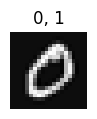

In [152]:
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap='gray')
plt.title(f"{y[random_index, 0]}, {Yhat[random_index, 0]}")
plt.axis("off")
plt.show()

#### 2.8 Numpy Broadcasting Tutorial

In the last example, **Z = XW + b** utilized Numpy broadcasting to expand the vector *b*

**XW** is a matrix-matrix operation with dimensions (m, $j_{1}$)($j_{1}$, $j_{2}$) which results in a matrix with dimension (m, *j_{2}*). To that, we add a vector **b** with dimension (1, $j_{2}$), b must be expanded to be a (m, $j_{2}$). 

In [157]:
a = np.array([1, 2, 3]).reshape(-1, 1) # (3, 1)
b = 5
print(f"(a + b).shape: {(a + b).shape}")

(a + b).shape: (3, 1)


In [160]:
a = np.array([1, 2, 3, 4]).reshape(-1, 1)
b = np.array([1, 2, 3]).reshape(1, -1)
print(a) 
print(b)
print(f"(a + b).shape {(a + b).shape}")

[[1]
 [2]
 [3]
 [4]]
[[1 2 3]]
(a + b).shape (4, 3)


This is the scenario in the dense layer we built above. Adding a 1-D vector b to a (m, j) matrix.